In [13]:
# =========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# Using Row 5 as Column Headers
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -----------------------------------------
# 1. LOAD DATA USING 5TH ROW AS HEADERS
# -----------------------------------------
df = pd.read_csv("osc_sheet_11_cleaned_1000.csv", header=6, encoding="utf-8")



print("Dataset shape:", df.shape)
print("\nColumn names:\n", df.columns)

df.head()



Dataset shape: (998, 31)

Column names:
 Index(['Company Name', 'Industry group', 'ISIN code', 'NSE symbol', 'Date',
       'Total income from continuing operations', 'Net sales',
       'Change in stock', 'Total expenses',
       'Raw materials, stocks, spares, purchase of finished goods',
       'Interest expenses', 'Depreciation', 'Total tax provision',
       'Net Profit/(Loss) for the period from continuing operations (after tax)',
       'Reported Profit after tax', 'PBT', 'PBDT', 'PBDIT', 'PBIT net of P&E',
       'Earnings per share before extraordinary item', 'Closing Price',
       'Date.1', 'Closing Price.1', 'Shares Outstanding',
       'Market Capitalisation', 'EPS', 'P/E', 'Number of Transactions',
       'Enterprise value', 'Industry P/E', 'Beta'],
      dtype='object')


,Company Name,Industry group,ISIN code,NSE symbol,Date,Total income from continuing operations,Net sales,Change in stock,Total expenses,"Raw materials, stocks, spares, purchase of finished goods",...,Date.1,Closing Price.1,Shares Outstanding,Market Capitalisation,EPS,P/E,Number of Transactions,Enterprise value,Industry P/E,Beta
0,3M India Ltd.,"Plastic furniture, floorings & miscellaneous i...",INE470A01017,3MINDIA,31-12-2022,943.41,932.22,-12.09,818.55,562.38,...,31-01-2023,23145.65,11265070,26073.736745,346.895314,66.722291,267,24891.636745,52.52,0.815759
1,A B B India Ltd.,"Generators, transformers & switchgears",INE117A01022,ABB,31-12-2022,2496.92,2426.91,-12.97,2178.04,1475.34,...,31-01-2023,2826.55,211908375,59896.961736,29.890749,94.562703,1956,56780.971736,78.35,0.768015
2,A C C Ltd.,Cement,INE012A01025,ACC,31-12-2022,4577.66,4536.97,-118.56,4348.65,1169.52,...,31-01-2023,1969.35,187787263,36981.884639,37.249065,52.869783,8437,30181.494639,48.83,0.976876
3,A D F Foods Ltd.,Processed foods,INE982B01027,ADFFOODS,31-12-2022,102.34,99.77,-3.64,79.48,38.81,...,31-01-2023,763.05,21972719,1676.628323,23.524626,32.436222,372,1585.448323,67.56,1.414542
4,A G I Greenpac Ltd.,Glass & glassware,INE415A01038,AGI,31-12-2022,570.40,567.30,12.31,529.48,199.24,...,31-01-2023,326.05,64697381,2109.458108,24.643965,13.230420,1510,3226.098108,33.34,1.149549


In [14]:

# -----------------------------------------
# 2. INITIAL DATA OVERVIEW
# -----------------------------------------
df.info()

# -----------------------------------------
# 3. MISSING DATA ANALYSIS (RAW)
# -----------------------------------------
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_percent
}).sort_values(by="Missing Percentage (%)", ascending=False)

print("Missing summary ")
print(missing_summary.head(31))

# -----------------------------------------
# 4. TYPE CONVERSION
# Convert all columns to numeric where possible
# -----------------------------------------

exclude_cols = ["Industry group","Company Name","ISIN code","NSE symbol","Date"]

cols_to_convert = df.columns.difference(exclude_cols)

df[cols_to_convert] = df[cols_to_convert].apply(
    pd.to_numeric, errors="coerce"
)






df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 31 columns):
 #   Column                                                                   Non-Null Count  Dtype  
---  ------                                                                   --------------  -----  
 0   Company Name                                                             998 non-null    object 
 1   Industry group                                                           998 non-null    object 
 2   ISIN code                                                                998 non-null    object 
 3   NSE symbol                                                               986 non-null    object 
 4   Date                                                                     994 non-null    object 
 5   Total income from continuing operations                                  994 non-null    float64
 6   Net sales                                                                9


Columns to drop (missing > 29% and < 100% ) — count: 2
                                                    Missing Count  \
Change in stock                                               306   
Raw materials, stocks, spares, purchase of fini...            300   

                                                    Missing Percentage (%)  
Change in stock                                                  30.661323  
Raw materials, stocks, spares, purchase of fini...               30.060120  
Shape after dropping high-missing columns: (998, 29)


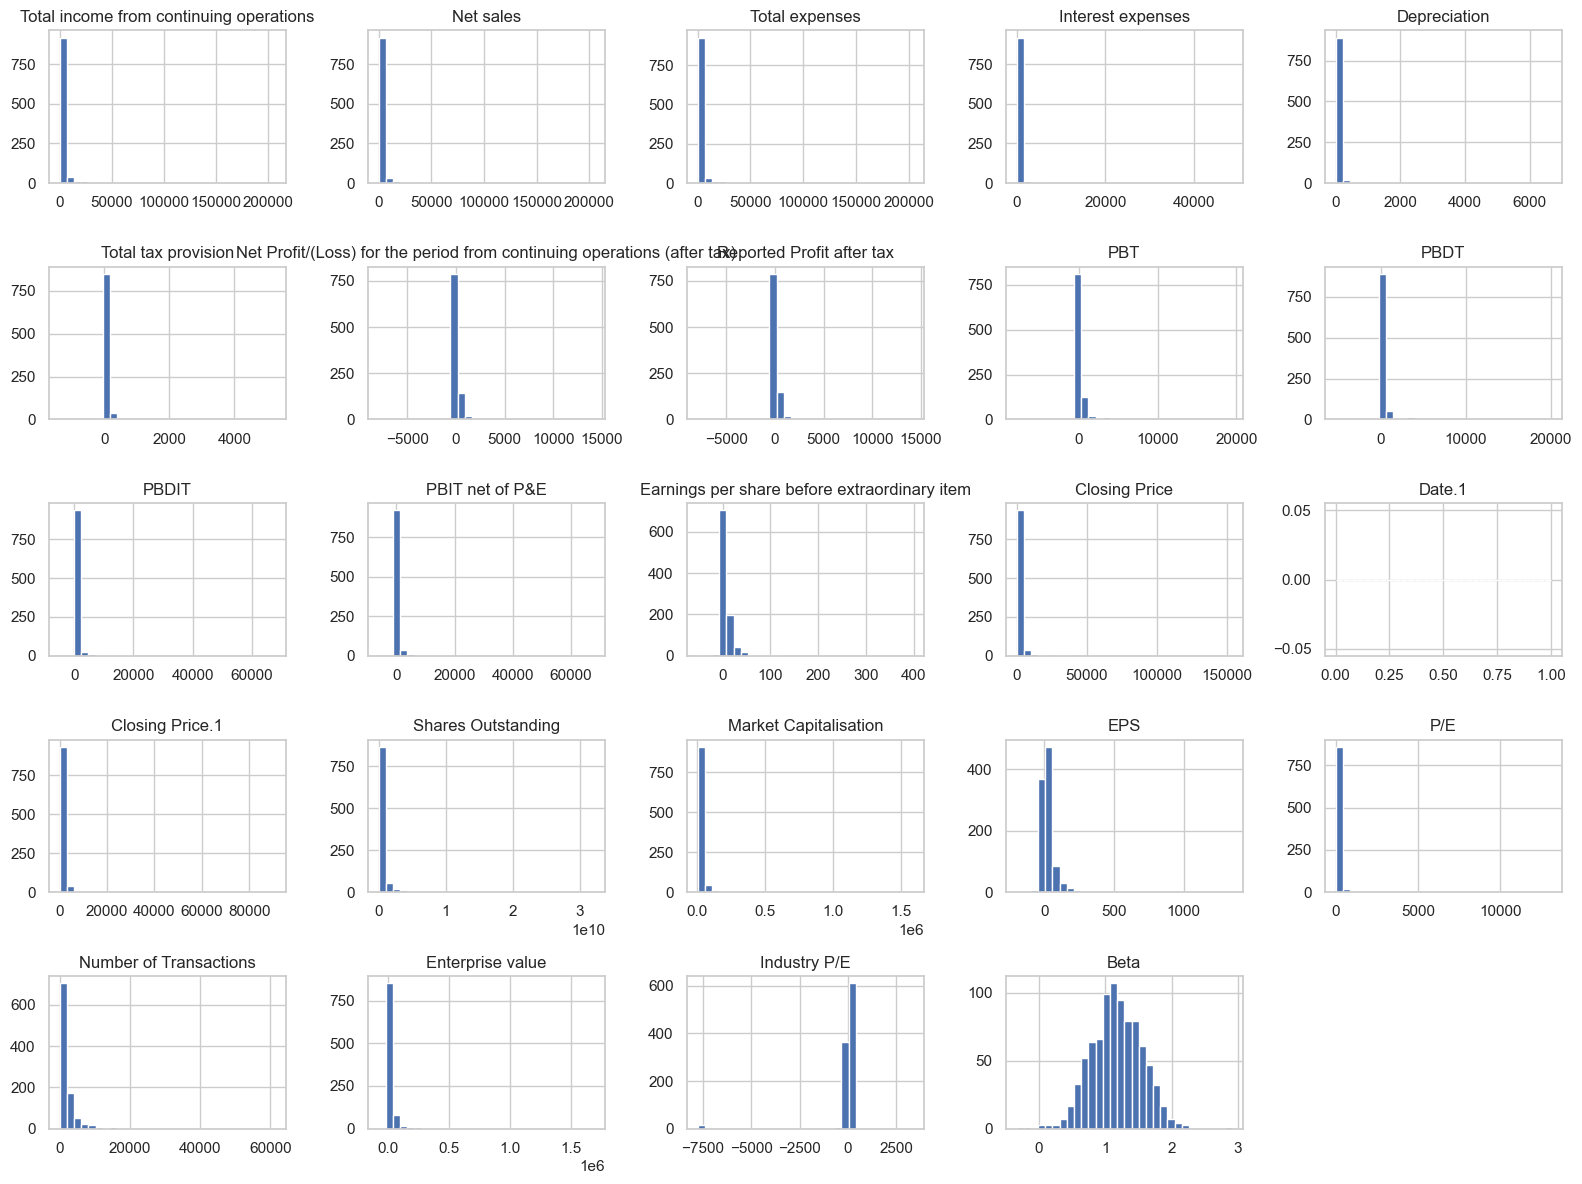

In [15]:

# -----------------------------------------
# 5. MISSING DATA ANALYSIS (POST CONVERSION)
# -----------------------------------------
missing_count_num = df.isnull().sum()
missing_percent_num = (missing_count_num / len(df)) * 100

missing_summary_num = pd.DataFrame({
    "Missing Count": missing_count_num,
    "Missing Percentage (%)": missing_percent_num
}).sort_values(by="Missing Percentage (%)", ascending=False)

missing_summary_num

# -----------------------------------------
# 6. dealing with missing data
# -----------------------------------------
#dropping colums with missing data greater than 29%
lower_threshold = 29
upper_threshold = 100

cols_to_drop = missing_summary_num[
    (missing_summary_num["Missing Percentage (%)"] > lower_threshold) &
    (missing_summary_num["Missing Percentage (%)"] < upper_threshold)
].index.tolist()

print(f"\nColumns to drop (missing > {lower_threshold}% and < {upper_threshold}% ) — count: {len(cols_to_drop)}")
if cols_to_drop:
    print(missing_summary_num.loc[cols_to_drop])
# Keep columns below threshold
df_reduced = df.drop(columns=cols_to_drop)


print("Shape after dropping high-missing columns:", df_reduced.shape)

# -----------------------------------------
# 7. SUMMARY STATISTICS
# -----------------------------------------
df_reduced.describe()

# -----------------------------------------
# 8. UNIVARIATE ANALYSIS (DISTRIBUTIONS)
# -----------------------------------------
df_reduced.hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

In [16]:
# Automatically detect P/E column
pe_col = next(col for col in df_reduced.columns if "P/E" in str(col).upper())
pe_series = df[pe_col]

observed_pe = pe_series.dropna()
missing_mask = pe_series.isna()

print("Missing P/E values:", missing_mask.sum())
np.random.seed(42)  # for reproducibility

imputed_values = np.random.choice(
    observed_pe,
    size=missing_mask.sum(),
    replace=True
)
df.loc[missing_mask, pe_col] = imputed_values


df.loc[missing_mask, pe_col] = imputed_values
comparison = pd.DataFrame({
    "Before Imputation": observed_pe.describe(percentiles=[0.25, 0.5, 0.75]),
    "After Imputation": df[pe_col].describe(percentiles=[0.25, 0.5, 0.75])
})

comparison


Missing P/E values: 104


,Before Imputation,After Imputation
count,894.000000,998.000000
mean,119.654231,115.937368
std,654.517638,630.063841
min,1.067340,1.067340
25%,17.055620,16.746713
50%,30.723654,30.462219
75%,55.286128,55.028266
max,13075.284991,13075.284991


In [17]:
import numpy as np

col_to_impute = "Beta"

# Ensure column is numeric
df_reduced[col_to_impute] = pd.to_numeric(df_reduced[col_to_impute], errors='coerce')

# Mask of missing values
missing_mask = df_reduced[col_to_impute].isna()

# Observed (non-missing) values
observed_values = df_reduced.loc[~missing_mask, col_to_impute].values

# Impute missing values by random sampling from observed
df_reduced.loc[missing_mask, col_to_impute] = np.random.choice(observed_values, size=missing_mask.sum(), replace=True)

# Check
print(f"Missing after imputation: {df_reduced[col_to_impute].isna().sum()}")
print(df_reduced[col_to_impute].describe())


Missing after imputation: 0
count    998.000000
mean       1.166725
std        0.380184
min       -0.338888
25%        0.902227
50%        1.160203
75%        1.427067
max        2.914559
Name: Beta, dtype: float64


In [18]:
exclude_cols = ['Beta', 'P', 'E']  # columns already handled

# Select only numeric columns
numeric_cols = df_reduced.select_dtypes(include=np.number).columns.tolist()

# Columns to impute: numeric and not in exclude list
cols_to_impute = [col for col in numeric_cols if col not in exclude_cols]

# Fill missing values with median
for col in cols_to_impute:
    if df_reduced[col].isna().sum() > 0:  # only if missing values exist
        median_val = df_reduced[col].median()
        df_reduced[col].fillna(median_val, inplace=True)

# Check missing values after median imputation
print("Missing values after median imputation for other numeric columns:")
print(df_reduced[cols_to_impute].isna().sum())


Missing values after median imputation for other numeric columns:
Total income from continuing operations                                      0
Net sales                                                                    0
Total expenses                                                               0
Interest expenses                                                            0
Depreciation                                                                 0
Total tax provision                                                          0
Net Profit/(Loss) for the period from continuing operations (after tax)      0
Reported Profit after tax                                                    0
PBT                                                                          0
PBDT                                                                         0
PBDIT                                                                        0
PBIT net of P&E                                                  

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [24]:
from sklearn.preprocessing import StandardScaler
df.columns = df.columns.str.strip()

industry_col = "Industry group"
mcap_col = "Market Capitalisation"
pe_col = "P/E"

df[[mcap_col, pe_col]] = df[[mcap_col, pe_col]].apply(
    pd.to_numeric, errors="coerce"
)

industry_medians = (
    df_reduced.groupby(industry_col)[[mcap_col, pe_col]]
      .median()
      .reset_index()
)

scaler = StandardScaler()
industry_medians[["mcap_z", "pe_z"]] = scaler.fit_transform(
    industry_medians[[mcap_col, pe_col]]
)

industry_medians["industry_score"] = (
    industry_medians["mcap_z"] + industry_medians["pe_z"]
) / 2

df = df_reduced.merge(
    industry_medians[[industry_col, "industry_score"]],
    on=industry_col,
    how="left"
)

df["industry_score"] = df["industry_score"].fillna(
    df["industry_score"].median()
)

df.to_csv("osc_sheet_11_with_industry_score.csv", index=False)


In [23]:
# Save the cleaned DataFrame to a new CSV
output_file = "cleaned_data.csv"  # choose your filename
df_reduced.to_csv(output_file, index=False)  # index=False to skip writing row numbers

print(f"Data successfully saved to {output_file}")


Data successfully saved to cleaned_data.csv


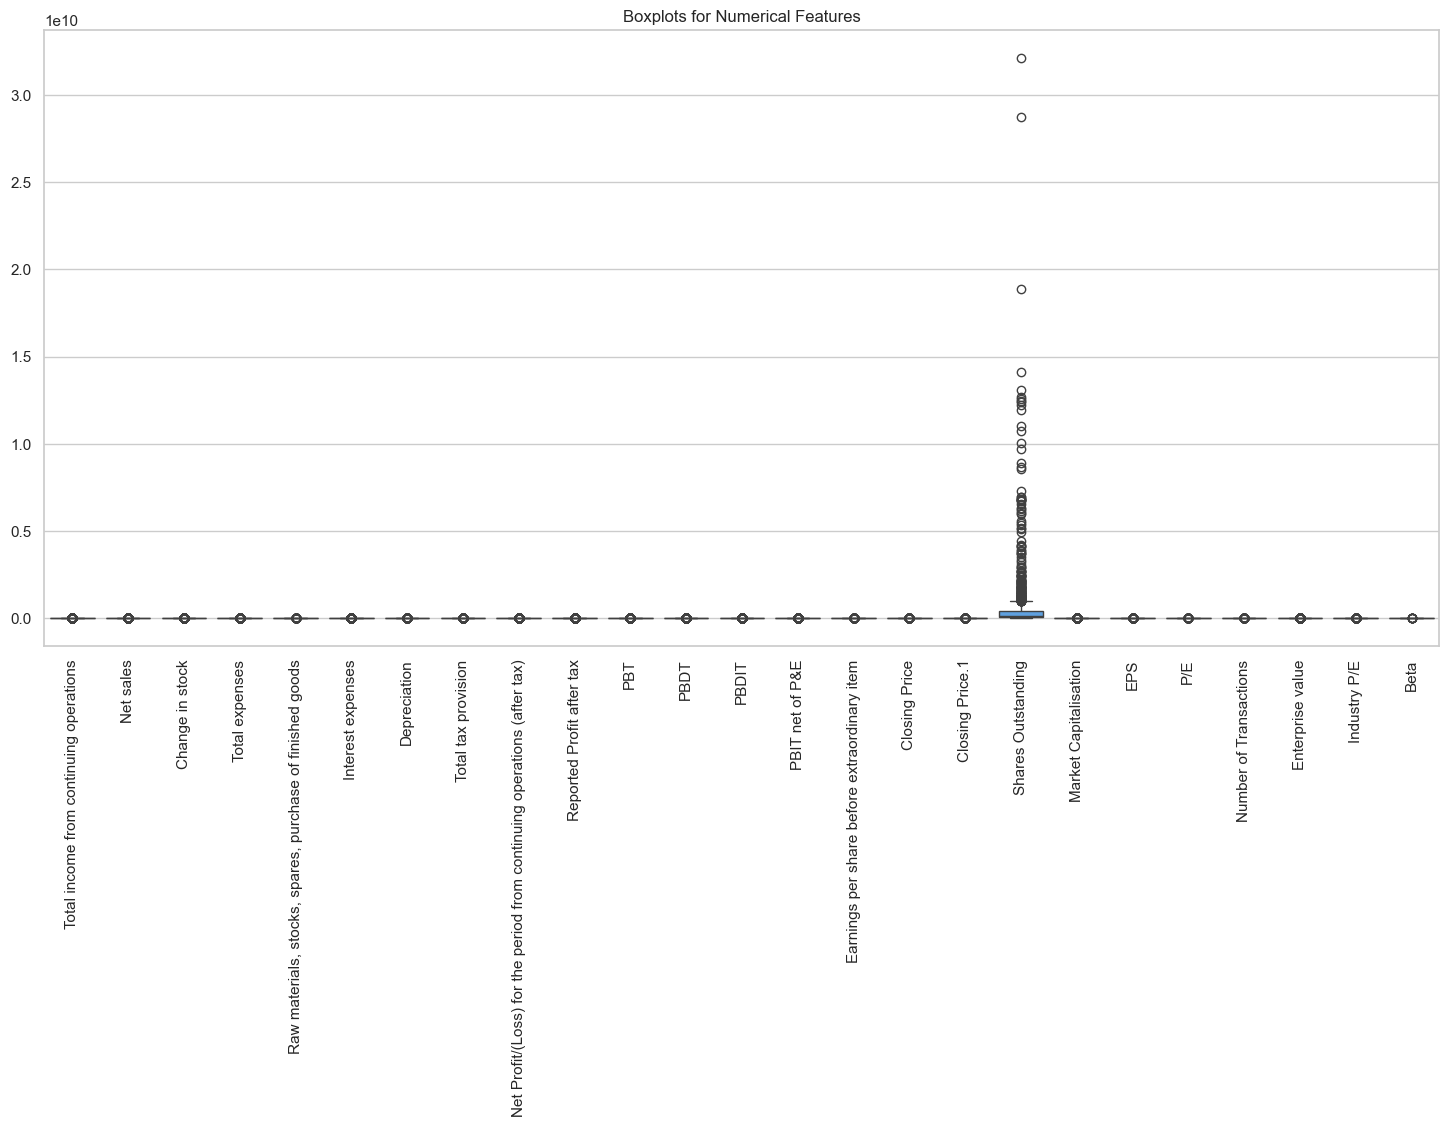

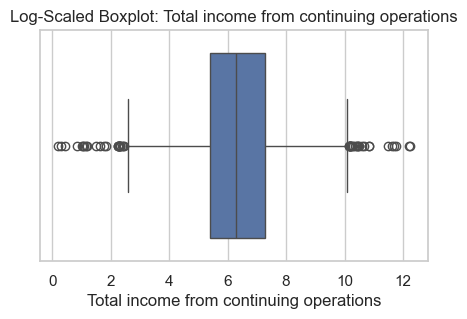

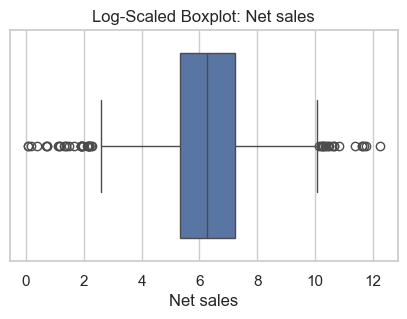

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


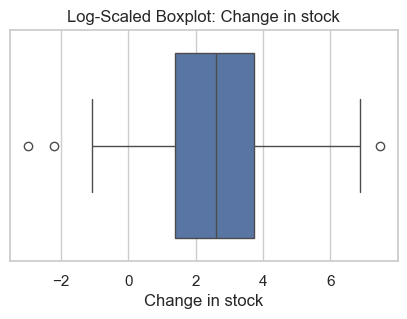

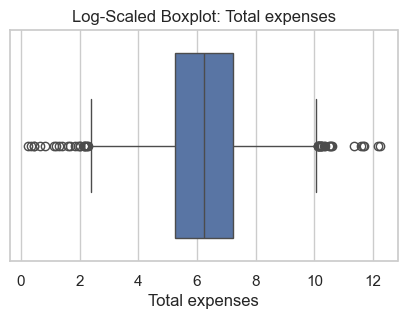

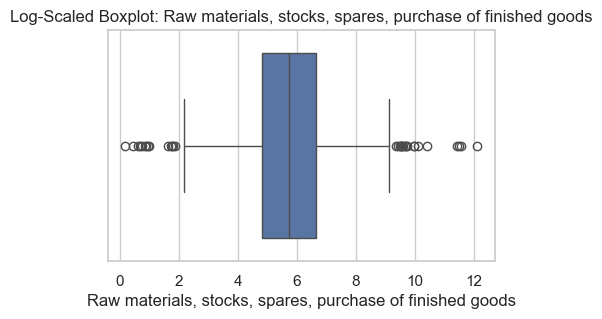

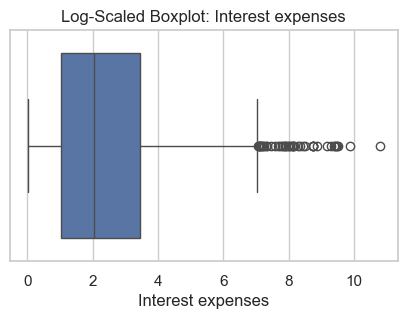

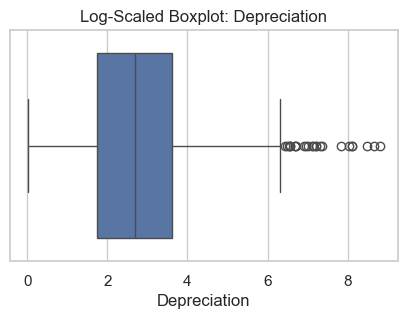

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


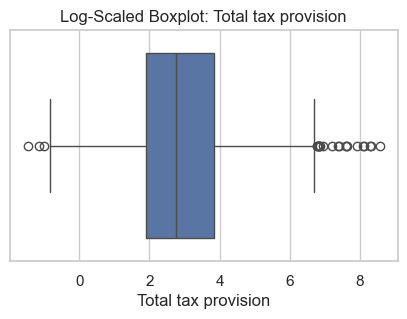

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


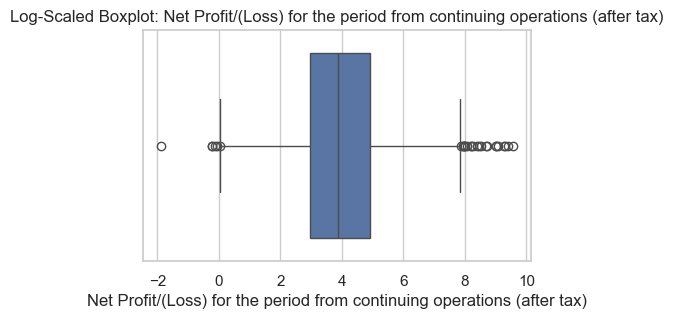

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


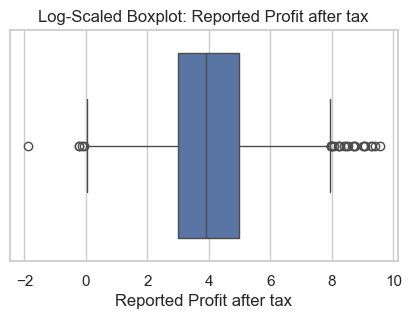

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


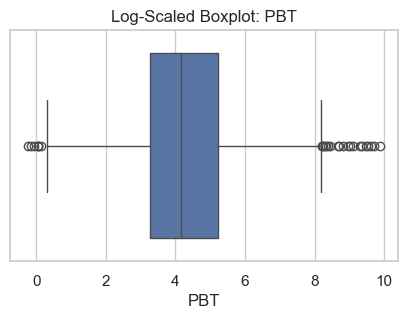

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


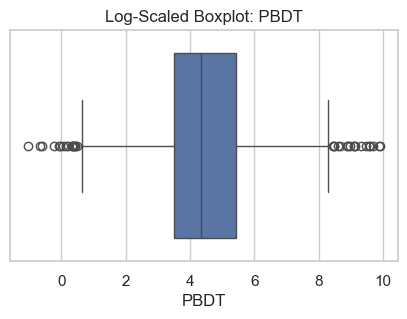

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


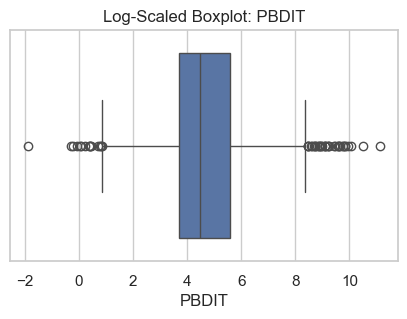

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


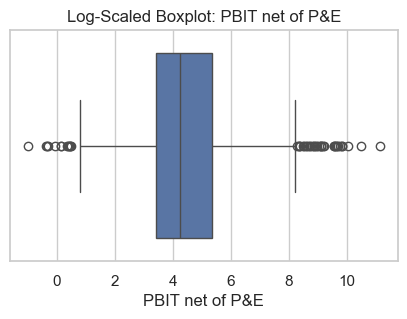

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


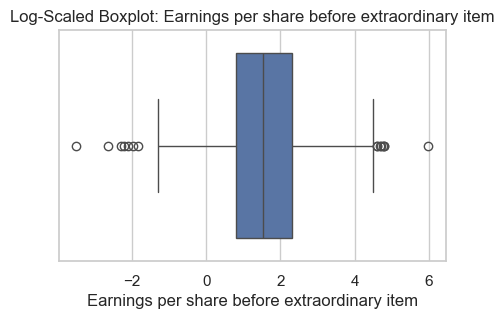

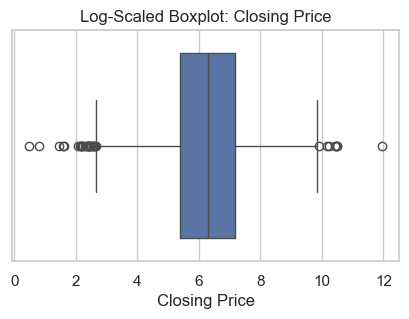

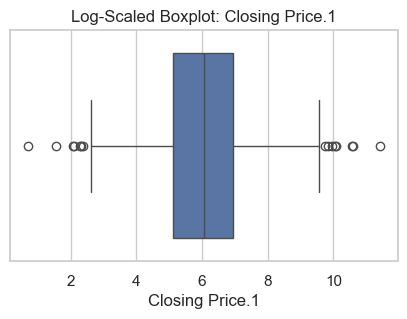

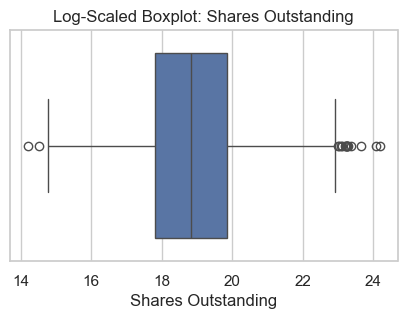

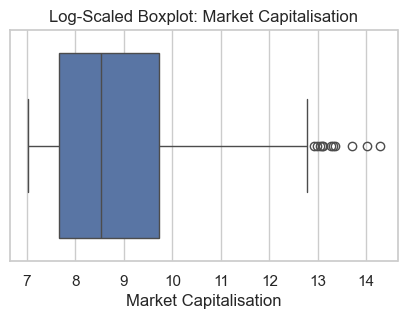

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


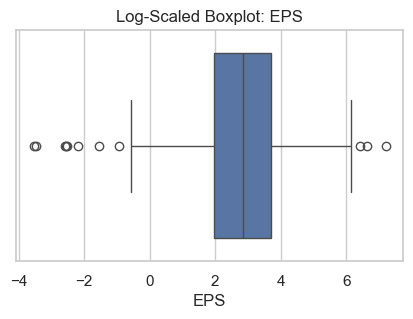

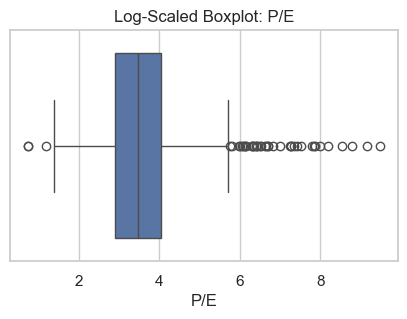

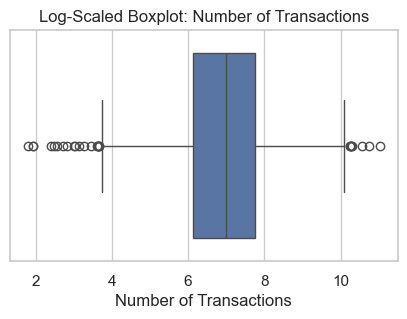

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


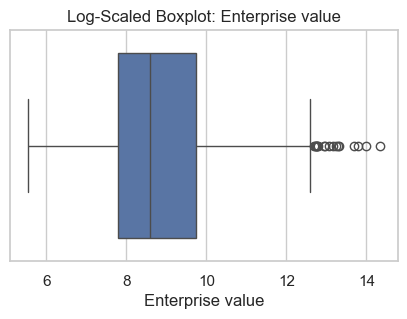

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


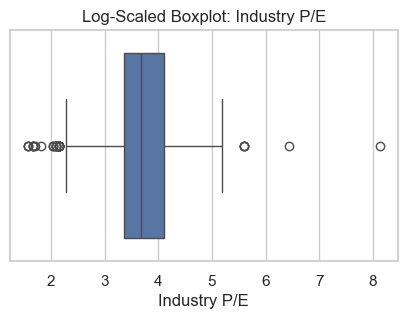

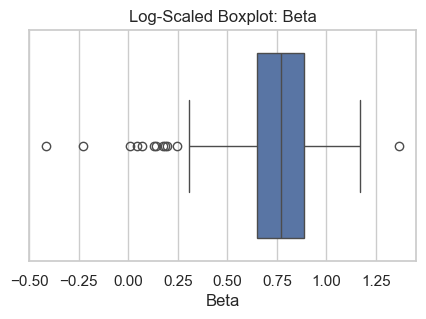

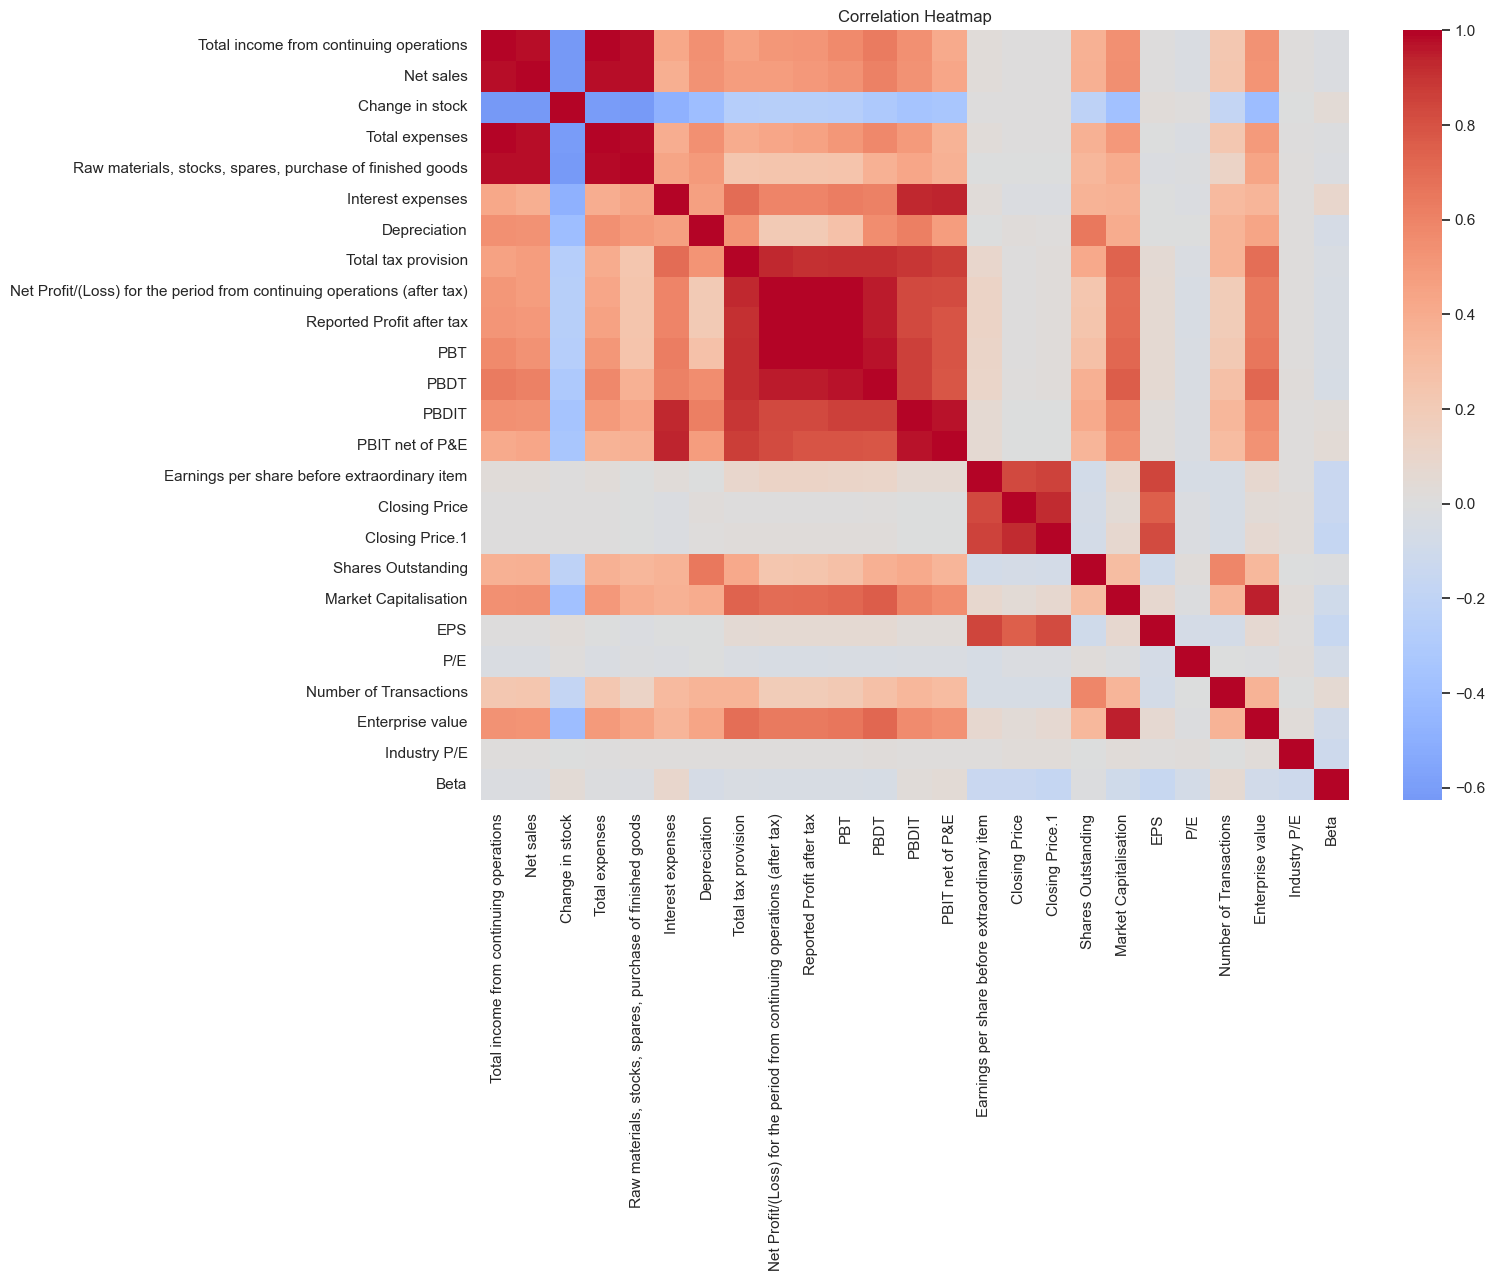

Outlier counts per column (IQR method):
Interest expenses                                                          166
Shares Outstanding                                                         146
Net Profit/(Loss) for the period from continuing operations (after tax)    144
PBIT net of P&E                                                            143
Change in stock                                                            142
Reported Profit after tax                                                  142
PBDIT                                                                      139
Enterprise value                                                           139
PBT                                                                        137
PBDT                                                                       134
Net sales                                                                  134
Total income from continuing operations                                    134
Market Capit

,Total income from continuing operations,Net sales,Change in stock,Total expenses,"Raw materials, stocks, spares, purchase of finished goods",Interest expenses,Depreciation,Total tax provision,Net Profit/(Loss) for the period from continuing operations (after tax),Reported Profit after tax,...,Closing Price,Closing Price.1,Shares Outstanding,Market Capitalisation,EPS,P/E,Number of Transactions,Enterprise value,Industry P/E,Beta
0,943.41,932.22,-12.09,818.55,562.38,0.56,13.88,38.46,112.77,112.77,...,34830.95,23145.65,11265070,26073.736745,346.895314,66.722291,267,24891.636745,52.52,0.815759
1,2496.92,2426.91,-12.97,2178.04,1475.34,7.24,26.82,94.32,305.91,305.32,...,5175.80,2826.55,211908375,59896.961736,29.890749,94.562703,1956,56780.971736,78.35,0.768015
2,4577.66,4536.97,-118.56,4348.65,1169.52,18.83,171.56,39.04,110.45,110.45,...,1752.65,1969.35,187787263,36981.884639,37.249065,52.869783,8437,30181.494639,48.83,0.976876
3,102.34,99.77,-3.64,79.48,38.81,0.16,1.44,7.48,19.22,19.22,...,209.45,763.05,21972719,1676.628323,23.524626,32.436222,372,1585.448323,67.56,1.414542
4,570.40,567.30,12.31,529.48,199.24,13.13,30.25,16.04,53.23,53.09,...,721.85,326.05,64697381,2109.458108,24.643965,13.230420,1510,3226.098108,33.34,1.149549


In [ ]:

# -----------------------------------------
# 9. BOXPLOTS (OUTLIER DETECTION)
# -----------------------------------------
plt.figure(figsize=(18, 8))
sns.boxplot(data=df_reduced)
plt.xticks(rotation=90)
plt.title("Boxplots for Numerical Features")
plt.show()

# -----------------------------------------
# 10. LOG-SCALED BOXPLOTS (FINANCIAL DATA)
# -----------------------------------------
for col in df_reduced.columns:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=np.log1p(df_reduced[col]))
    plt.title(f"Log-Scaled Boxplot: {col}")
    plt.show()

# -----------------------------------------
# 11. CORRELATION ANALYSIS
# -----------------------------------------
corr = df_reduced.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------------------
# 12. IQR-BASED OUTLIER COUNT
# -----------------------------------------
Q1 = df_reduced.quantile(0.25)
Q3 = df_reduced.quantile(0.75)
IQR = Q3 - Q1

# Count outliers per column using the IQR rule
outlier_mask = (
    (df_reduced < (Q1 - 1.5 * IQR)) |
    (df_reduced > (Q3 + 1.5 * IQR))
)
outlier_count = outlier_mask.sum()

# Print per-column outlier counts (sorted), plus totals
outlier_count_sorted = outlier_count.sort_values(ascending=False)
print("Outlier counts per column (IQR method):")
print(outlier_count_sorted)
total_outlier_entries = int(outlier_count.sum())
print(f"\nTotal number of outlier entries across all columns: {total_outlier_entries}")
rows_with_outlier = int(outlier_mask.any(axis=1).sum())
print(f"Number of rows with at least one outlier: {rows_with_outlier}")

# -----------------------------------------
# 13. FINAL CLEAN DATA PREVIEW
# -----------------------------------------
df_reduced.head()
